In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.layers import LSTM, Dense, Input, Layer
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Attention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
data.tail(25)

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2024-07-03 23:00:00,0.0000,"Kozani, Greece",20.0,20.0,10.0,52.53,0.0,0.0,0.0,24.5,11.2,320.0,1006.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 00:00:00,0.0000,"Kozani, Greece",21.0,21.0,9.0,46.18,0.0,0.0,0.0,14.0,14.8,330.0,1006.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 01:00:00,0.0000,"Kozani, Greece",20.0,20.0,9.0,49.11,0.0,0.0,0.0,7.2,14.8,360.0,1007.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 02:00:00,0.0000,"Kozani, Greece",20.0,20.0,8.0,45.90,0.1,0.0,0.0,4.7,14.8,340.0,1006.0,98.1,NaN,0.0,0.0,0.0,"Rain, Overcast",rain
2024-07-04 03:00:00,0.0000,"Kozani, Greece",17.0,17.0,12.0,72.39,0.0,0.0,0.0,9.7,20.5,330.0,1006.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 04:00:00,0.0000,"Kozani, Greece",16.0,16.0,12.0,77.15,0.0,0.0,0.0,12.6,14.8,330.0,1007.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 05:00:00,0.0000,"Kozani, Greece",16.0,16.0,11.0,72.21,0.0,0.0,0.0,14.4,13.0,310.0,1007.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 06:00:00,0.0053,"Kozani, Greece",17.0,17.0,11.0,67.76,0.0,0.0,0.0,15.5,16.6,340.0,1007.0,88.0,10.0,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2024-07-04 07:00:00,0.0739,"Kozani, Greece",17.0,17.0,10.0,63.39,0.0,0.0,0.0,16.9,16.6,350.0,1007.0,88.0,10.0,76.0,0.3,1.0,Partially cloudy,partly-cloudy-day


In [4]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [5]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

In [6]:
data.isna().sum()

Kwh                   0
name                  0
temp                  0
feelslike             0
dew                   0
humidity              0
precip                0
snow                 53
snowdepth             0
windgust              0
windspeed             0
winddir               0
sealevelpressure      0
cloudcover            0
visibility          278
solarradiation        0
solarenergy           1
uvindex               1
conditions            0
icon                  0
dtype: int64

In [7]:
data_picked = data[['Kwh', 'temp', 'dew', 'humidity', 'precip', 'windgust', 'windspeed', 'winddir', 'cloudcover', 'solarradiation']]

In [8]:
data_picked

,Kwh,temp,dew,humidity,precip,windgust,windspeed,winddir,cloudcover,solarradiation
datetime,,,,,,,,,,
2022-01-01 00:00:00,0.0000,6.0,2.0,75.51,0.0,19.8,7.6,240.0,0.0,0.0
2022-01-01 01:00:00,0.0000,6.0,2.0,75.51,0.0,19.8,5.4,298.1,0.0,0.0
2022-01-01 02:00:00,0.0000,4.9,2.0,81.61,0.0,20.5,7.6,301.0,40.9,0.0
2022-01-01 03:00:00,0.0000,4.0,1.0,80.80,0.0,20.5,3.6,294.8,38.0,0.0
2022-01-01 04:00:00,0.0000,3.0,2.0,93.14,0.0,19.8,5.4,292.3,41.7,0.0
...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,0.0592,24.0,10.0,41.15,0.0,22.0,9.4,180.0,79.3,207.0
2024-07-04 20:00:00,0.0085,23.0,9.0,40.87,0.1,22.0,3.6,172.8,81.7,103.0
2024-07-04 21:00:00,0.0000,21.0,10.0,49.39,0.1,14.4,0.0,0.0,63.7,9.0


In [9]:
data_picked.describe()

,Kwh,temp,dew,humidity,precip,windgust,windspeed,winddir,cloudcover,solarradiation
count,21983.000000,21983.000000,21983.000000,21983.000000,21983.000000,21983.000000,21983.000000,21983.000000,21983.000000,21983.000000
mean,0.151445,13.414748,4.569608,60.205863,0.066022,16.050139,7.875818,217.827658,47.738025,176.537262
std,0.222754,8.779722,6.781981,22.578909,1.003953,9.320562,6.221712,136.029381,38.837197,264.425914
min,0.000000,-10.000000,-20.000000,8.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,7.000000,0.000000,42.300000,0.000000,10.000000,3.600000,90.000000,4.800000,0.000000
50%,0.001200,13.000000,5.000000,59.280000,0.000000,13.700000,7.600000,290.000000,49.100000,11.000000
75%,0.278400,20.000000,10.000000,77.910000,0.000000,19.700000,11.200000,340.000000,88.300000,298.000000
max,0.809800,40.000000,23.000000,100.000000,94.634000,72.000000,46.400000,360.000000,100.000000,1157.000000


In [10]:
tc = data_picked.corr()

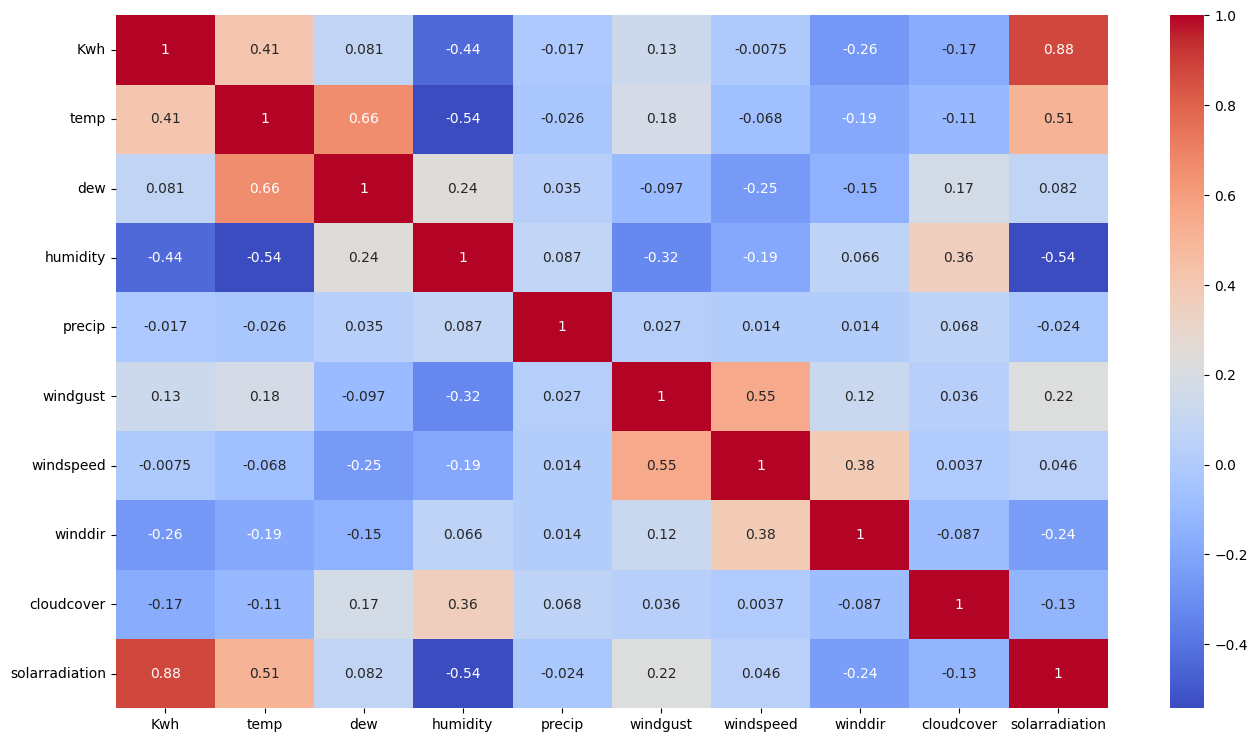

In [11]:
plt.figure(figsize= (16, 9))
sns.heatmap(tc, annot= True, cmap = "coolwarm")
plt.show()

# Temperature Forecast 

In [12]:
temperature_data = data[['dew', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation', 'temp']]

In [13]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :6]]
        x.append(row)
        real_val = df_as_np[i + size][6]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [14]:
scaler = StandardScaler()
df_sacled_temp = scaler.fit_transform(temperature_data.iloc[:, :6])
df_sacled_temp = pd.DataFrame(df_sacled_temp)
df_sacled_temp.head(20)

,0,1,2,3,4,5
0,-0.378896,0.677822,0.402331,0.163000,-1.229211,-0.667640
1,-0.378896,0.677822,0.402331,0.590124,-1.229211,-0.667640
2,-0.378896,0.947992,0.477435,0.611443,-0.176073,-0.667640
3,-0.526349,0.912117,0.477435,0.565864,-0.250745,-0.667640
4,-0.378896,1.458657,0.402331,0.547485,-0.155474,-0.667640
5,-0.378896,1.457328,0.380872,0.574686,-0.209547,-0.667640
6,-0.378896,1.177858,0.520352,1.045183,-0.078226,-0.667640
7,-0.378896,0.677822,0.670561,0.898152,0.416156,-0.667640
8,-0.378896,0.918760,0.670561,0.898152,0.055669,-0.644949
9,-0.231443,0.924518,0.745665,0.530576,0.058244,-0.580657


In [15]:
df_sacled_temp = df_sacled_temp.reset_index(drop=True)
df_picked_temp = temperature_data.reset_index(drop=True)

df_sacled_temp = pd.concat([df_sacled_temp, df_picked_temp["temp"]], axis=1)
df_sacled_temp

,0,1,2,3,4,5,temp
0,-0.378896,0.677822,0.402331,0.163000,-1.229211,-0.667640,6.0
1,-0.378896,0.677822,0.402331,0.590124,-1.229211,-0.667640,6.0
2,-0.378896,0.947992,0.477435,0.611443,-0.176073,-0.667640,4.9
3,-0.526349,0.912117,0.477435,0.565864,-0.250745,-0.667640,4.0
4,-0.378896,1.458657,0.402331,0.547485,-0.155474,-0.667640,3.0
...,...,...,...,...,...,...,...
21978,0.800727,-0.843987,0.638373,-0.278091,0.812692,0.115206,24.0
21979,0.653274,-0.856388,0.638373,-0.331022,0.874490,-0.278108,23.0
21980,0.800727,-0.479036,-0.177047,-1.601364,0.411006,-0.633603,21.0
21981,0.948180,-0.179635,-0.219964,-1.601364,0.457355,-0.667640,20.0


In [16]:
x_temp, y_temp = df_to_x_y(df_sacled_temp, size= 24)
x_temp.shape, y_temp.shape

((21959, 24, 6), (21959,))

In [17]:
x_train_temp , y_train_temp = x_temp[:int(0.8*len(x_temp))], y_temp[: int(0.8*len(y_temp))]
x_val_temp, y_val_temp = x_temp[int(0.8*len(x_temp)): int(0.9*len(x_temp))], y_temp[int(0.8*len(y_temp)): int(0.9*len(y_temp))]
x_test_temp, y_test_temp = x_temp[int(0.9*len(x_temp)):], y_temp[int(0.9*len(y_temp)):]

x_train_temp.shape, y_train_temp.shape, x_val_temp.shape, y_val_temp.shape, x_test_temp.shape, y_test_temp.shape

((17567, 24, 6), (17567,), (2196, 24, 6), (2196,), (2196, 24, 6), (2196,))

In [18]:
checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [19]:
input_shape = (24, 6)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 64)    │     18,176 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 64)    │        256 │ lstm[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 64)    │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24, 64)    │      4,160 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,913 (89.50 KB)

 Trainable params: 22,657 (88.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [20]:
lr_schedule = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [21]:
model_1.fit(x_train_temp, y_train_temp, 
            validation_data = (x_val_temp, y_val_temp), 
            epochs = 40,
            batch_size= 32,
            callbacks=[checkpoint_callback]
            )

Epoch 1/40
542/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 84.2915 - root_mean_squared_error: 8.9489
Epoch 1: val_loss improved from inf to 10.25625, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 83.7258 - root_mean_squared_error: 8.9168 - val_loss: 10.2562 - val_root_mean_squared_error: 3.2054
Epoch 2/40
540/549 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18.1651 - root_mean_squared_error: 4.2583
Epoch 2: val_loss did not improve from 10.25625
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 18.1429 - root_mean_squared_error: 4.2557 - val_loss: 13.2232 - val_root_mean_squared_error: 3.6382
Epoch 3/40
543/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.6016 - root_mean_squared_error: 3.2505
Epoch 3: val_loss did not improve from 10.25625
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 10.6075 - root_mean_squared_error: 3.2514 - val_loss: 12.6253 - val_root_mean_squared_error: 3.5331
Epoch 4/40
543/5

In [22]:
test_predictions_temp = model_1.predict(x_test_temp).flatten()
test_results_temp = pd.DataFrame({"Val Predictions" : test_predictions_temp, "Real Data" : y_test_temp})
test_results_temp
test_results_temp.index = temperature_data.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


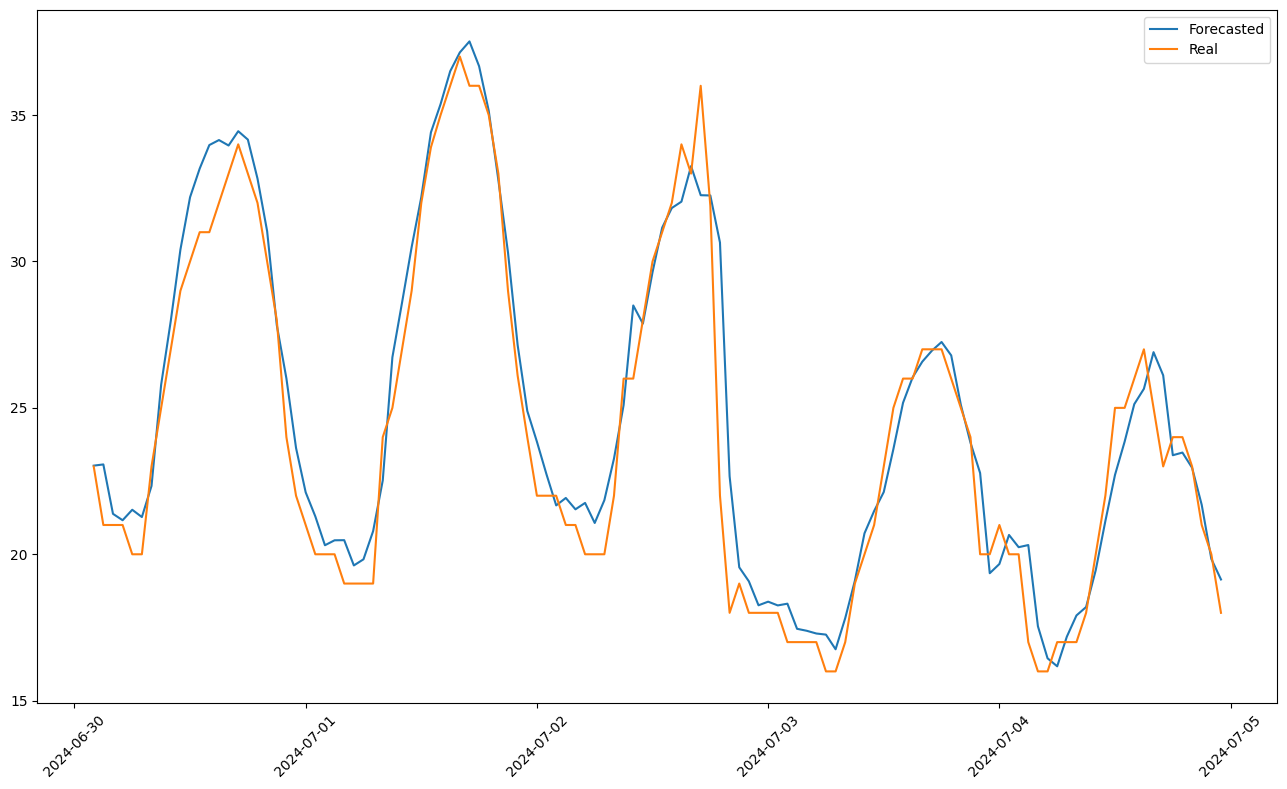

In [23]:
plt.figure(figsize= (16, 9))
plt.plot(test_results_temp["Val Predictions"][-118 :], label = "Forecasted")
plt.plot(test_results_temp["Real Data"][-118 :], label = "Real")
plt.legend()
plt.xticks(rotation = 45)
plt.show()

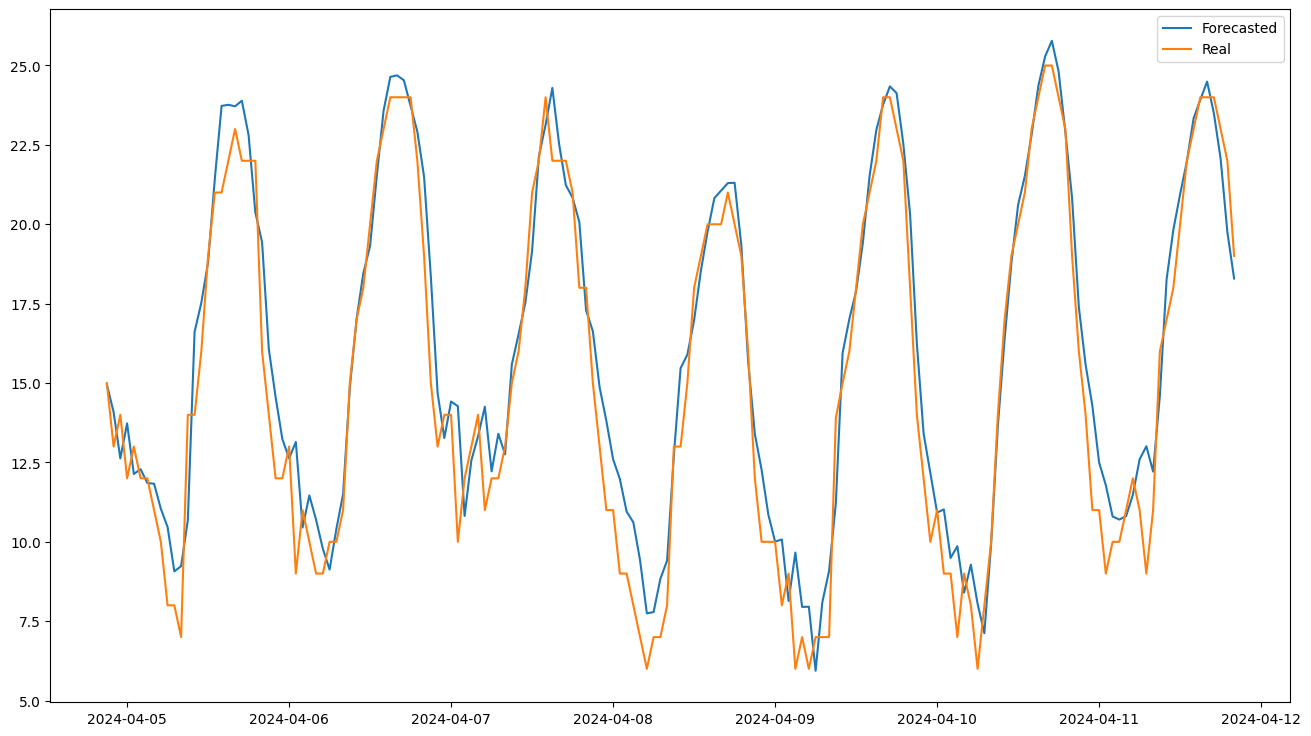

In [24]:
plt.figure(figsize= (16, 9))
plt.plot(test_results_temp["Val Predictions"][9:177], label = "Forecasted")
plt.plot(test_results_temp["Real Data"][9:177], label = "Real")
plt.legend()
plt.show()

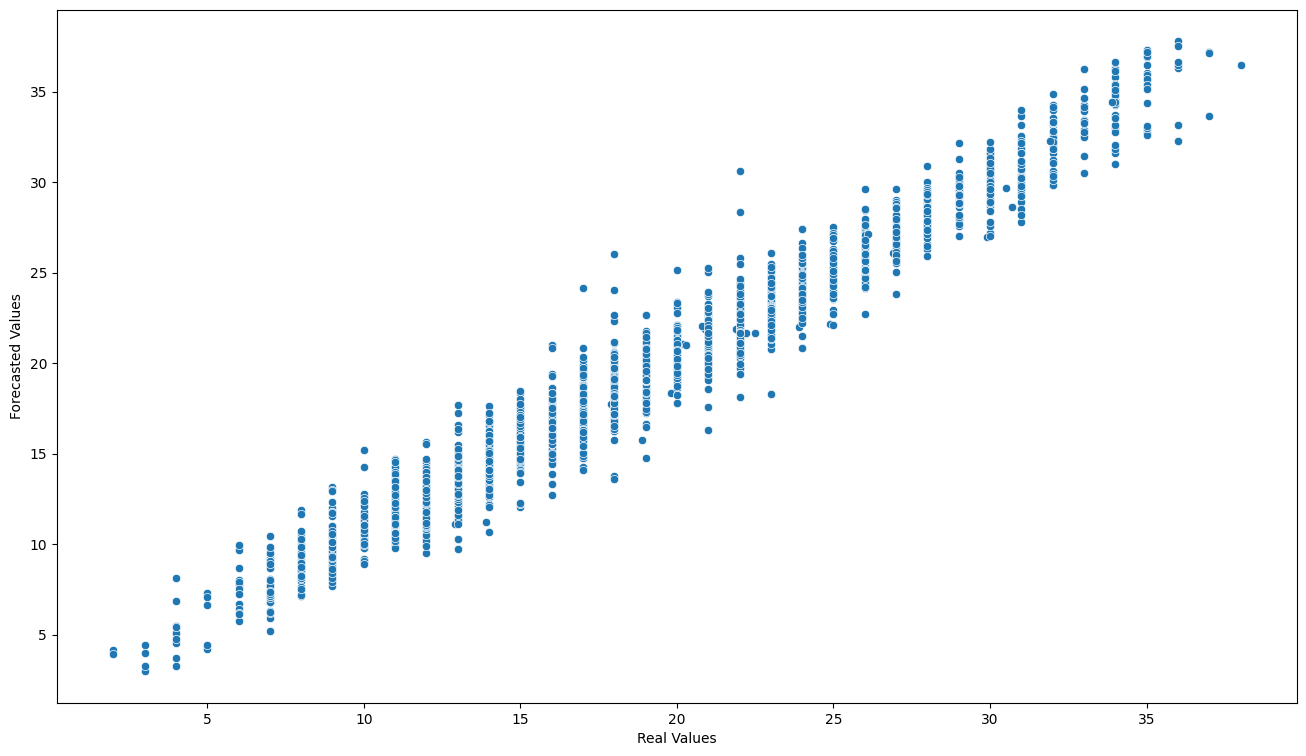

In [25]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Real Data", y = "Val Predictions", data = test_results_temp)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.show()

In [26]:
mse_temp = mean_squared_error(test_results_temp["Real Data"], test_results_temp["Val Predictions"])
print(f" Mean Squared Error = {round(mse_temp, 5)} \n Root Mean Squared Error = {round(np.sqrt(mse_temp), 5)}")

ss_total = np.sum((test_results_temp["Real Data"] - test_results_temp["Real Data"].mean()) ** 2)
residual = np.sum((test_results_temp["Real Data"] - test_results_temp["Val Predictions"]) ** 2)
r_squared_temp = 1 - (residual / ss_total)

r_squared_temp ,mse_temp #0.96605

 Mean Squared Error = 1.97271 
 Root Mean Squared Error = 1.40453


(0.961200969575042, 1.9727065873507705)

# Humidity Forecast

In [27]:
humidity_data = data[['temp', 'dew', 'windgust', 'cloudcover', 'solarradiation', 'humidity']]

In [28]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :5]]
        x.append(row)
        real_val = df_as_np[i + size][5]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [29]:
scaler = StandardScaler()
df_sacled_humidity = scaler.fit_transform(humidity_data.iloc[:, :5])
df_sacled_humidity = pd.DataFrame(df_sacled_humidity)
df_sacled_humidity.head(20)

,0,1,2,3,4
0,-0.844550,-0.378896,0.402331,-1.229211,-0.667640
1,-0.844550,-0.378896,0.402331,-1.229211,-0.667640
2,-0.969842,-0.378896,0.477435,-0.176073,-0.667640
3,-1.072353,-0.526349,0.477435,-0.250745,-0.667640
4,-1.186254,-0.378896,0.402331,-0.155474,-0.667640
5,-1.186254,-0.378896,0.380872,-0.209547,-0.667640
6,-1.072353,-0.378896,0.520352,-0.078226,-0.667640
7,-0.844550,-0.378896,0.670561,0.416156,-0.667640
8,-0.958452,-0.378896,0.670561,0.055669,-0.644949
9,-0.844550,-0.231443,0.745665,0.058244,-0.580657


In [30]:
df_sacled_humidity = df_sacled_humidity.reset_index(drop=True)
df_picked_humidity = humidity_data.reset_index(drop=True)

df_sacled_humidity = pd.concat([df_sacled_humidity, df_picked_humidity["humidity"]], axis=1)
df_sacled_humidity

,0,1,2,3,4,humidity
0,-0.844550,-0.378896,0.402331,-1.229211,-0.667640,75.51
1,-0.844550,-0.378896,0.402331,-1.229211,-0.667640,75.51
2,-0.969842,-0.378896,0.477435,-0.176073,-0.667640,81.61
3,-1.072353,-0.526349,0.477435,-0.250745,-0.667640,80.80
4,-1.186254,-0.378896,0.402331,-0.155474,-0.667640,93.14
...,...,...,...,...,...,...
21978,1.205675,0.800727,0.638373,0.812692,0.115206,41.15
21979,1.091774,0.653274,0.638373,0.874490,-0.278108,40.87
21980,0.863971,0.800727,-0.177047,0.411006,-0.633603,49.39
21981,0.750070,0.948180,-0.219964,0.457355,-0.667640,56.15


In [31]:
x_humidity, y_humidity = df_to_x_y(df_sacled_humidity, size= 24)
x_humidity.shape, y_humidity.shape

((21959, 24, 5), (21959,))

In [32]:
x_train_humidity, y_train_humidity = x_humidity[:int(0.8*len(x_humidity))], y_humidity[: int(0.8*len(y_humidity))]
x_val_humidity, y_val_humidity = x_humidity[int(0.8*len(x_humidity)): int(0.9*len(x_humidity))], y_humidity[int(0.8*len(y_humidity)): int(0.9*len(y_humidity))]
x_test_humidity, y_test_humidity = x_humidity[int(0.9*len(x_humidity)):], y_humidity[int(0.9*len(y_humidity)):]

x_train_humidity.shape, y_train_humidity.shape, x_val_humidity.shape, y_val_humidity.shape, x_test_humidity.shape, y_test_humidity.shape

((17567, 24, 5), (17567,), (2196, 24, 5), (2196,), (2196, 24, 5), (2196,))

In [33]:
input_shape = (24, 5)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 24, 64)    │     17,920 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 24, 64)    │      4,160 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,657 (88.50 KB)

 Trainable params: 22,401 (87.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [34]:
model_1.fit(x_train_humidity, y_train_humidity, 
            validation_data = (x_val_humidity, y_val_humidity), 
            epochs = 40,
            batch_size= 32,
            callbacks=[checkpoint_callback]
            )

Epoch 1/40
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2999.0334 - root_mean_squared_error: 54.5097
Epoch 1: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2997.4900 - root_mean_squared_error: 54.4949 - val_loss: 1497.7820 - val_root_mean_squared_error: 38.6897
Epoch 2/40
546/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 907.9608 - root_mean_squared_error: 30.0990
Epoch 2: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 908.6780 - root_mean_squared_error: 30.1108 - val_loss: 2013.0990 - val_root_mean_squared_error: 44.8893
Epoch 3/40
544/549 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 451.3400 - root_mean_squared_error: 20.7383
Epoch 3: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 449.0528 - root_mean_squared_error: 20.6816 - val_loss: 157.4213 - val_root_mean_squared_error: 12.5735
Epoch 4/40
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 106.1529 - root_mean_squ

In [35]:
test_predictions_humidity = model_1.predict(x_test_humidity).flatten()
test_results_humidity = pd.DataFrame({"Val Predictions" : test_predictions_humidity, "Real Data" : y_test_humidity})
test_results_humidity
test_results_humidity.index = humidity_data.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


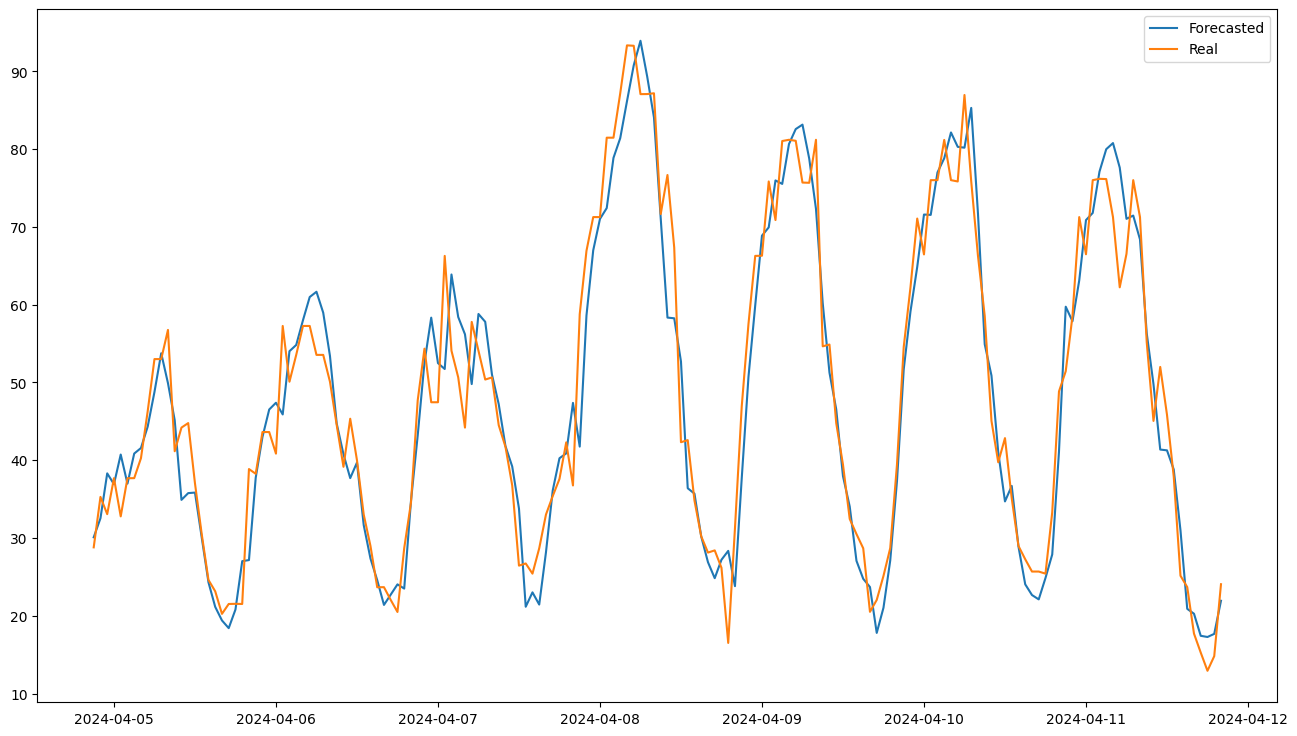

In [36]:
plt.figure(figsize= (16, 9))
plt.plot(test_results_humidity["Val Predictions"][9:177], label = "Forecasted")
plt.plot(test_results_humidity["Real Data"][9:177], label = "Real")
plt.legend()
plt.show()

In [37]:
mse_humidity = mean_squared_error(test_results_humidity["Real Data"], test_results_humidity["Val Predictions"])
print(f" Mean Squared Error = {round(mse_humidity, 5)} \n Root Mean Squared Error = {round(np.sqrt(mse_humidity), 5)}")

ss_total = np.sum((test_results_humidity["Real Data"] - test_results_humidity["Real Data"].mean()) ** 2)
residual = np.sum((test_results_humidity["Real Data"] - test_results_humidity["Val Predictions"]) ** 2)
r_squared_humidity = 1 - (residual / ss_total)

r_squared_humidity ,mse_humidity

 Mean Squared Error = 40.21505 
 Root Mean Squared Error = 6.34153


(0.9259034005279903, 40.215049612454465)

# WindGust Forecast

In [38]:
windgust_data = data[['humidity', 'windspeed', 'cloudcover', 'windgust']]

In [39]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :4]]
        x.append(row)
        real_val = df_as_np[i + size][4]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [40]:
scaler = StandardScaler()
df_sacled_windgust = scaler.fit_transform(windgust_data.iloc[:, :4])
df_sacled_windgust = pd.DataFrame(df_sacled_windgust)
df_sacled_windgust.head(20)

,0,1,2,3
0,0.677822,-0.044332,-1.229211,0.402331
1,0.677822,-0.397941,-1.229211,0.402331
2,0.947992,-0.044332,-0.176073,0.477435
3,0.912117,-0.687257,-0.250745,0.477435
4,1.458657,-0.397941,-0.155474,0.402331
5,1.457328,-0.687257,-0.209547,0.380872
6,1.177858,0.534300,-0.078226,0.520352
7,0.677822,0.534300,0.416156,0.670561
8,0.918760,1.096858,0.055669,0.670561
9,0.924518,0.534300,0.058244,0.745665


In [41]:
df_sacled_windgust = df_sacled_windgust.reset_index(drop=True)
df_picked_windgust = windgust_data.reset_index(drop=True)

df_sacled_windgust = pd.concat([df_sacled_windgust, df_picked_windgust["windgust"]], axis=1)
df_sacled_windgust

,0,1,2,3,windgust
0,0.677822,-0.044332,-1.229211,0.402331,19.8
1,0.677822,-0.397941,-1.229211,0.402331,19.8
2,0.947992,-0.044332,-0.176073,0.477435,20.5
3,0.912117,-0.687257,-0.250745,0.477435,20.5
4,1.458657,-0.397941,-0.155474,0.402331,19.8
...,...,...,...,...,...
21978,-0.843987,0.244984,0.812692,0.638373,22.0
21979,-0.856388,-0.687257,0.874490,0.638373,22.0
21980,-0.479036,-1.265889,0.411006,-0.177047,14.4
21981,-0.179635,-1.265889,0.457355,-0.219964,14.0


In [42]:
x_windgust, y_windgust = df_to_x_y(df_sacled_windgust, size= 24)
x_windgust.shape, y_windgust.shape

((21959, 24, 4), (21959,))

In [43]:
x_train_windgust, y_train_windgust= x_windgust[:int(0.8*len(x_windgust))], y_windgust[: int(0.8*len(y_windgust))]
x_val_windgust, y_val_windgust = x_windgust[int(0.8*len(x_windgust)): int(0.9*len(x_windgust))], y_windgust[int(0.8*len(y_windgust)): int(0.9*len(y_windgust))]
x_test_windgust, y_test_windgust = x_windgust[int(0.9*len(x_windgust)):], y_windgust[int(0.9*len(y_windgust)):]

x_train_windgust.shape, y_train_windgust.shape, x_val_windgust.shape, y_val_windgust.shape, x_test_windgust.shape, y_test_windgust.shape

((17567, 24, 4), (17567,), (2196, 24, 4), (2196,), (2196, 24, 4), (2196,))

In [44]:
input_shape = (24, 4)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 24, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 24, 64)    │     17,664 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_2         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 24, 64)    │          0 │ attention_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 24, 64)    │      4,160 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,401 (87.50 KB)

 Trainable params: 22,145 (86.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [45]:
model_1.fit(x_train_windgust, y_train_windgust, 
            validation_data = (x_val_windgust, y_val_windgust), 
            epochs = 40,
            batch_size= 32,
            callbacks=[checkpoint_callback]
            )

Epoch 1/40
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 176.9522 - root_mean_squared_error: 13.1755
Epoch 1: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 176.8478 - root_mean_squared_error: 13.1714 - val_loss: 62.6939 - val_root_mean_squared_error: 7.9221
Epoch 2/40
539/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 52.1409 - root_mean_squared_error: 7.2061
Epoch 2: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 51.9853 - root_mean_squared_error: 7.1951 - val_loss: 41.0501 - val_root_mean_squared_error: 6.4061
Epoch 3/40
543/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38.1024 - root_mean_squared_error: 6.1724
Epoch 3: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 38.0920 - root_mean_squared_error: 6.1716 - val_loss: 34.8678 - val_root_mean_squared_error: 5.9064
Epoch 4/40
540/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 36.7068 - root_mean_squared_error: 6.0576


In [46]:
test_predictions_windgust = model_1.predict(x_test_windgust).flatten()
test_results_windgust = pd.DataFrame({"Val Predictions" : test_predictions_windgust, "Real Data" : y_test_windgust})
test_results_windgust
test_results_windgust.index = windgust_data.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


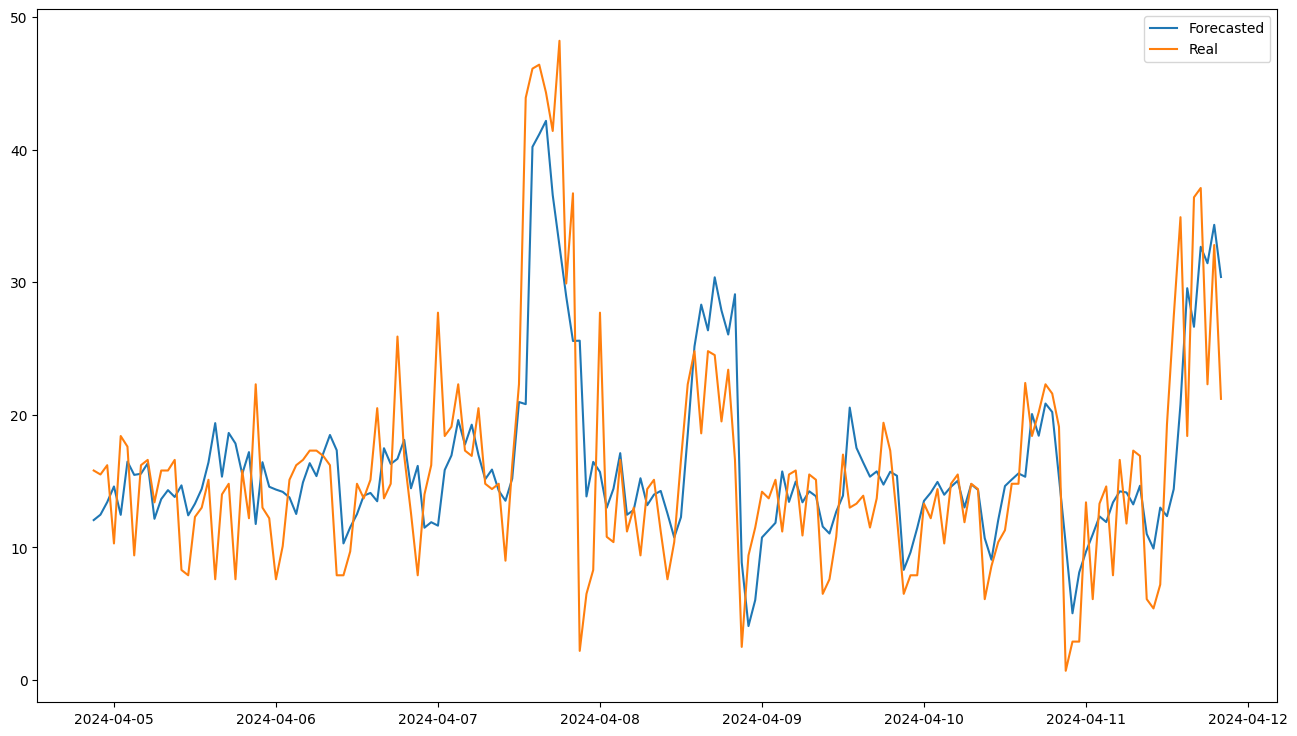

In [47]:
plt.figure(figsize= (16, 9))
plt.plot(test_results_windgust["Val Predictions"][9:177], label = "Forecasted")
plt.plot(test_results_windgust["Real Data"][9:177], label = "Real")
plt.legend()
plt.show()

In [48]:
mse_windgust = mean_squared_error(test_results_windgust["Real Data"], test_results_windgust["Val Predictions"])
print(f" Mean Squared Error = {round(mse_windgust, 5)} \n Root Mean Squared Error = {round(np.sqrt(mse_windgust), 5)}")

ss_total = np.sum((test_results_windgust["Real Data"] - test_results_windgust["Real Data"].mean()) ** 2)
residual = np.sum((test_results_windgust["Real Data"] - test_results_windgust["Val Predictions"]) ** 2)
r_squared_windgust = 1 - (residual / ss_total)

r_squared_windgust ,mse_windgust

 Mean Squared Error = 31.63287 
 Root Mean Squared Error = 5.62431


(0.6301832139613099, 31.632873676624563)

# Wind Direction Forecast

In [49]:
winddir_data = data[['temp', 'windspeed', 'solarradiation', 'winddir']]

In [50]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :4]]
        x.append(row)
        real_val = df_as_np[i + size][4]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [51]:
scaler = StandardScaler()
df_scaled_winddir = scaler.fit_transform(winddir_data.iloc[:, :4])
df_scaled_winddir = pd.DataFrame(df_scaled_winddir)
df_scaled_winddir.head(20)


,0,1,2,3
0,-0.844550,-0.044332,-0.667640,0.163000
1,-0.844550,-0.397941,-0.667640,0.590124
2,-0.969842,-0.044332,-0.667640,0.611443
3,-1.072353,-0.687257,-0.667640,0.565864
4,-1.186254,-0.397941,-0.667640,0.547485
5,-1.186254,-0.687257,-0.667640,0.574686
6,-1.072353,0.534300,-0.667640,1.045183
7,-0.844550,0.534300,-0.667640,0.898152
8,-0.958452,1.096858,-0.644949,0.898152
9,-0.844550,0.534300,-0.580657,0.530576


In [52]:
df_scaled_winddir = df_scaled_winddir.reset_index(drop=True)
df_picked_winddir = winddir_data.reset_index(drop=True)

df_scaled_winddir = pd.concat([df_scaled_winddir, df_picked_winddir["winddir"]], axis=1)
df_scaled_winddir


,0,1,2,3,winddir
0,-0.844550,-0.044332,-0.667640,0.163000,240.0
1,-0.844550,-0.397941,-0.667640,0.590124,298.1
2,-0.969842,-0.044332,-0.667640,0.611443,301.0
3,-1.072353,-0.687257,-0.667640,0.565864,294.8
4,-1.186254,-0.397941,-0.667640,0.547485,292.3
...,...,...,...,...,...
21978,1.205675,0.244984,0.115206,-0.278091,180.0
21979,1.091774,-0.687257,-0.278108,-0.331022,172.8
21980,0.863971,-1.265889,-0.633603,-1.601364,0.0
21981,0.750070,-1.265889,-0.667640,-1.601364,0.0


In [53]:
x_winddir, y_winddir = df_to_x_y(df_scaled_winddir, size=24)
x_winddir.shape, y_winddir.shape

x_train_winddir, y_train_winddir = x_winddir[:int(0.8*len(x_winddir))], y_winddir[:int(0.8*len(y_winddir))]
x_val_winddir, y_val_winddir = x_winddir[int(0.8*len(x_winddir)):int(0.9*len(x_winddir))], y_winddir[int(0.8*len(y_winddir)):int(0.9*len(y_winddir))]
x_test_winddir, y_test_winddir = x_winddir[int(0.9*len(x_winddir)):], y_winddir[int(0.9*len(y_winddir)):]

x_train_winddir.shape, y_train_winddir.shape, x_val_winddir.shape, y_val_winddir.shape, x_test_winddir.shape, y_test_winddir.shape


((17567, 24, 4), (17567,), (2196, 24, 4), (2196,), (2196, 24, 4), (2196,))

In [54]:
input_shape = (24, 4)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 24, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 24, 64)    │     17,664 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_3[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_3         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 64)    │          0 │ attention_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 24, 64)    │      4,160 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,401 (87.50 KB)

 Trainable params: 22,145 (86.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [55]:
model_1.fit(x_train_winddir, y_train_winddir, 
            validation_data=(x_val_winddir, y_val_winddir), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback]
            )


Epoch 1/40
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 61944.2969 - root_mean_squared_error: 248.8017
Epoch 1: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 61932.6016 - root_mean_squared_error: 248.7777 - val_loss: 40300.4688 - val_root_mean_squared_error: 200.6316
Epoch 2/40
540/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 36461.8789 - root_mean_squared_error: 190.7384
Epoch 2: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 36367.7734 - root_mean_squared_error: 190.4865 - val_loss: 22306.5586 - val_root_mean_squared_error: 149.1735
Epoch 3/40
541/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 23764.4141 - root_mean_squared_error: 154.1375
Epoch 3: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 23749.5508 - root_mean_squared_error: 154.0891 - val_loss: 18205.2910 - val_root_mean_squared_error: 134.6615
Epoch 4/40
548/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2

In [56]:
test_predictions_winddir = model_1.predict(x_test_winddir).flatten()
test_results_winddir = pd.DataFrame({"Val Predictions": test_predictions_winddir, "Real Data": y_test_winddir})
test_results_winddir
test_results_winddir.index = winddir_data.iloc[-2196:].index


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


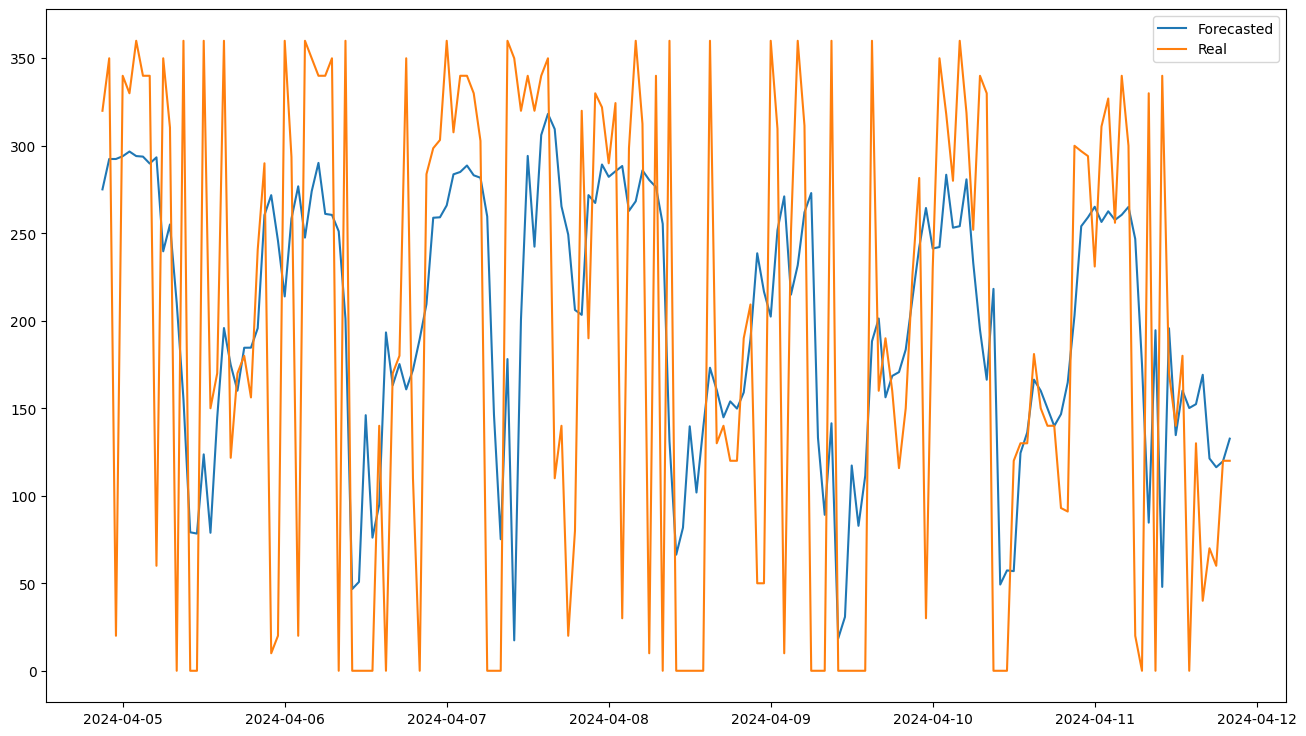

In [57]:
plt.figure(figsize=(16, 9))
plt.plot(test_results_winddir["Val Predictions"][9:177], label="Forecasted")
plt.plot(test_results_winddir["Real Data"][9:177], label="Real")
plt.legend()
plt.show()


In [58]:
mse_winddir = mean_squared_error(test_results_winddir["Real Data"], test_results_winddir["Val Predictions"])
print(f"Mean Squared Error = {round(mse_winddir, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_winddir), 5)}")

ss_total = np.sum((test_results_winddir["Real Data"] - test_results_winddir["Real Data"].mean()) ** 2)
residual = np.sum((test_results_winddir["Real Data"] - test_results_winddir["Val Predictions"]) ** 2)
r_squared_winddir = 1 - (residual / ss_total)

r_squared_winddir, mse_winddir


Mean Squared Error = 12834.77297 
Root Mean Squared Error = 113.29066


(0.3140237012098607, 12834.77297020884)

# Cloud Cover Forecast

In [59]:
cloudcov_data = data[['humidity', 'cloudcover']]

In [60]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :2]]
        x.append(row)
        real_val = df_as_np[i + size][2]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [61]:
scaler = StandardScaler()
df_scaled_cloudcov = scaler.fit_transform(cloudcov_data.iloc[:, :2])
df_scaled_cloudcov = pd.DataFrame(df_scaled_cloudcov)
df_scaled_cloudcov.head(20)


,0,1
0,0.677822,-1.229211
1,0.677822,-1.229211
2,0.947992,-0.176073
3,0.912117,-0.250745
4,1.458657,-0.155474
5,1.457328,-0.209547
6,1.177858,-0.078226
7,0.677822,0.416156
8,0.918760,0.055669
9,0.924518,0.058244


In [62]:
df_scaled_cloudcov = df_scaled_cloudcov.reset_index(drop=True)
df_picked_cloudcov = cloudcov_data.reset_index(drop=True)

df_scaled_cloudcov = pd.concat([df_scaled_cloudcov, df_picked_cloudcov["cloudcover"]], axis=1)
df_scaled_cloudcov


,0,1,cloudcover
0,0.677822,-1.229211,0.0
1,0.677822,-1.229211,0.0
2,0.947992,-0.176073,40.9
3,0.912117,-0.250745,38.0
4,1.458657,-0.155474,41.7
...,...,...,...
21978,-0.843987,0.812692,79.3
21979,-0.856388,0.874490,81.7
21980,-0.479036,0.411006,63.7
21981,-0.179635,0.457355,65.5


In [63]:
x_cloudcov, y_cloudcov = df_to_x_y(df_scaled_cloudcov, size=24)
x_cloudcov.shape, y_cloudcov.shape

((21959, 24, 2), (21959,))

In [64]:
y_cloudcov

array([ 8.5,  0. ,  0. , ..., 63.7, 65.5, 68.3])

In [65]:
x_train_cloudcov, y_train_cloudcov = x_cloudcov[:int(0.8*len(x_cloudcov))], y_cloudcov[:int(0.8*len(y_cloudcov))]
x_val_cloudcov, y_val_cloudcov = x_cloudcov[int(0.8*len(x_cloudcov)):int(0.9*len(x_cloudcov))], y_cloudcov[int(0.8*len(y_cloudcov)):int(0.9*len(y_cloudcov))]
x_test_cloudcov, y_test_cloudcov = x_cloudcov[int(0.9*len(x_cloudcov)):], y_cloudcov[int(0.9*len(y_cloudcov)):]

x_train_cloudcov.shape, y_train_cloudcov.shape, x_val_cloudcov.shape, y_val_cloudcov.shape, x_test_cloudcov.shape, y_test_cloudcov.shape


((17567, 24, 2), (17567,), (2196, 24, 2), (2196,), (2196, 24, 2), (2196,))

In [66]:
input_shape = (24, 2)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 24, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 24, 64)    │     17,152 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_4[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_4         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 24, 64)    │          0 │ attention_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 24, 64)    │      4,160 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,889 (85.50 KB)

 Trainable params: 21,633 (84.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [67]:
model_1.fit(x_train_cloudcov, y_train_cloudcov, 
            validation_data=(x_val_cloudcov, y_val_cloudcov), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback]
            )

Epoch 1/40
546/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2600.9324 - root_mean_squared_error: 50.7998
Epoch 1: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2595.7795 - root_mean_squared_error: 50.7467 - val_loss: 725.6255 - val_root_mean_squared_error: 26.8875
Epoch 2/40
541/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 668.1609 - root_mean_squared_error: 25.7871
Epoch 2: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 666.1942 - root_mean_squared_error: 25.7482 - val_loss: 399.6020 - val_root_mean_squared_error: 19.9772
Epoch 3/40
544/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 386.0639 - root_mean_squared_error: 19.6446
Epoch 3: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 386.0627 - root_mean_squared_error: 19.6446 - val_loss: 360.8013 - val_root_mean_squared_error: 18.9736
Epoch 4/40
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 395.3654 - root_mean_squar

In [68]:
test_predictions_cloudcov = model_1.predict(x_test_cloudcov).flatten()
test_results_cloudcov = pd.DataFrame({"Val Predictions": test_predictions_cloudcov, "Real Data": y_test_cloudcov})
test_results_cloudcov
test_results_cloudcov.index = cloudcov_data.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


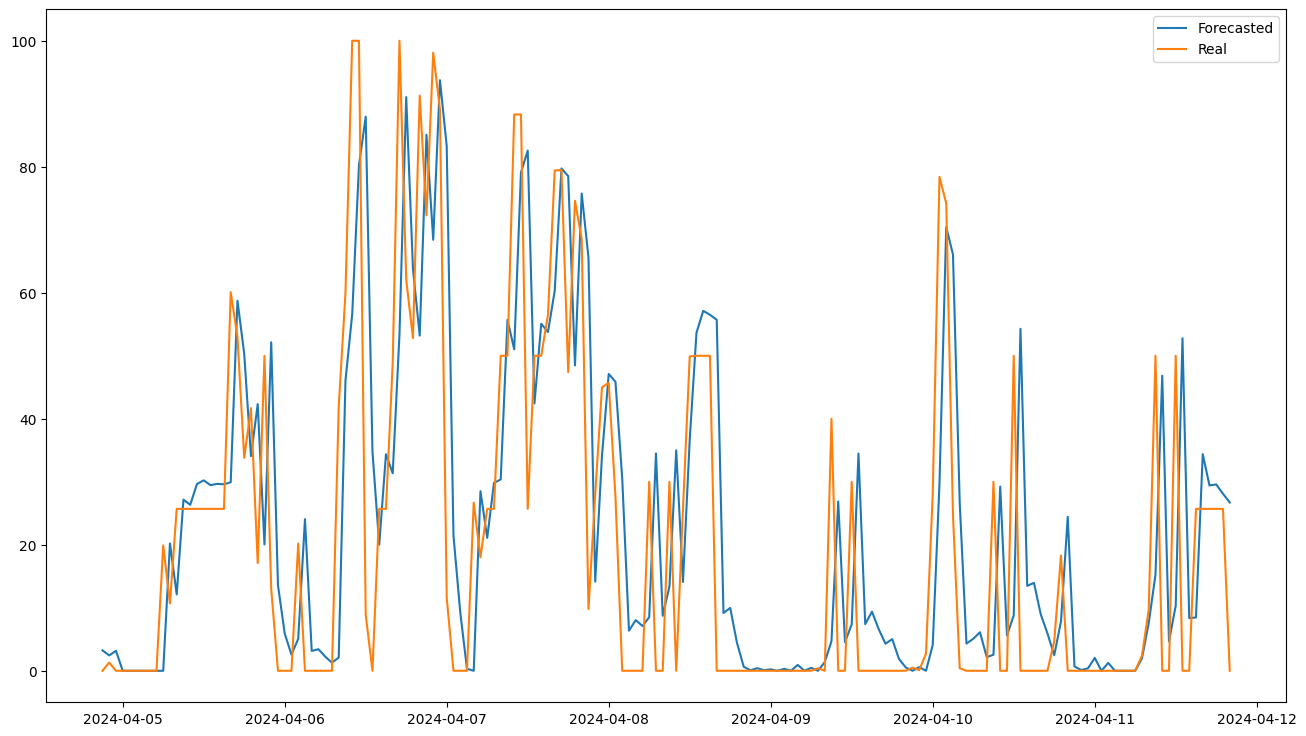

In [69]:
plt.figure(figsize=(16, 9))
plt.plot(test_results_cloudcov["Val Predictions"][9:177], label="Forecasted")
plt.plot(test_results_cloudcov["Real Data"][9:177], label="Real")
plt.legend()
plt.show()


In [70]:
mse_cloudcov = mean_squared_error(test_results_cloudcov["Real Data"], test_results_cloudcov["Val Predictions"])
print(f"Mean Squared Error = {round(mse_cloudcov, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_cloudcov), 5)}")

ss_total = np.sum((test_results_cloudcov["Real Data"] - test_results_cloudcov["Real Data"].mean()) ** 2)
residual = np.sum((test_results_cloudcov["Real Data"] - test_results_cloudcov["Val Predictions"]) ** 2)
r_squared_cloudcov = 1 - (residual / ss_total)

r_squared_cloudcov, mse_cloudcov

Mean Squared Error = 424.19369 
Root Mean Squared Error = 20.59596


(0.690587480472173, 424.1936939733383)

# Solar Radiation Forecast

In [71]:
solarrad_data = data[['temp', 'humidity', 'windgust', 'windspeed', 'solarradiation']]

In [72]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :5]]
        x.append(row)
        real_val = df_as_np[i + size][5]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [73]:
scaler = StandardScaler()
df_scaled_solarrad = scaler.fit_transform(solarrad_data.iloc[:, :5])
df_scaled_solarrad = pd.DataFrame(df_scaled_solarrad)
df_scaled_solarrad.head(20)


,0,1,2,3,4
0,-0.844550,0.677822,0.402331,-0.044332,-0.667640
1,-0.844550,0.677822,0.402331,-0.397941,-0.667640
2,-0.969842,0.947992,0.477435,-0.044332,-0.667640
3,-1.072353,0.912117,0.477435,-0.687257,-0.667640
4,-1.186254,1.458657,0.402331,-0.397941,-0.667640
5,-1.186254,1.457328,0.380872,-0.687257,-0.667640
6,-1.072353,1.177858,0.520352,0.534300,-0.667640
7,-0.844550,0.677822,0.670561,0.534300,-0.667640
8,-0.958452,0.918760,0.670561,1.096858,-0.644949
9,-0.844550,0.924518,0.745665,0.534300,-0.580657


In [74]:
df_scaled_solarrad = df_scaled_solarrad.reset_index(drop=True)
df_picked_solarrad = solarrad_data.reset_index(drop=True)

df_scaled_solarrad = pd.concat([df_scaled_solarrad, df_picked_solarrad["solarradiation"]], axis=1)
df_scaled_solarrad


,0,1,2,3,4,solarradiation
0,-0.844550,0.677822,0.402331,-0.044332,-0.667640,0.0
1,-0.844550,0.677822,0.402331,-0.397941,-0.667640,0.0
2,-0.969842,0.947992,0.477435,-0.044332,-0.667640,0.0
3,-1.072353,0.912117,0.477435,-0.687257,-0.667640,0.0
4,-1.186254,1.458657,0.402331,-0.397941,-0.667640,0.0
...,...,...,...,...,...,...
21978,1.205675,-0.843987,0.638373,0.244984,0.115206,207.0
21979,1.091774,-0.856388,0.638373,-0.687257,-0.278108,103.0
21980,0.863971,-0.479036,-0.177047,-1.265889,-0.633603,9.0
21981,0.750070,-0.179635,-0.219964,-1.265889,-0.667640,0.0


In [75]:
x_solarrad, y_solarrad = df_to_x_y(df_scaled_solarrad, size=24)
x_solarrad.shape, y_solarrad.shape

x_train_solarrad, y_train_solarrad = x_solarrad[:int(0.8*len(x_solarrad))], y_solarrad[:int(0.8*len(y_solarrad))]
x_val_solarrad, y_val_solarrad = x_solarrad[int(0.8*len(x_solarrad)):int(0.9*len(x_solarrad))], y_solarrad[int(0.8*len(y_solarrad)):int(0.9*len(y_solarrad))]
x_test_solarrad, y_test_solarrad = x_solarrad[int(0.9*len(x_solarrad)):], y_solarrad[int(0.9*len(y_solarrad)):]

x_train_solarrad.shape, y_train_solarrad.shape, x_val_solarrad.shape, y_val_solarrad.shape, x_test_solarrad.shape, y_test_solarrad.shape


((17567, 24, 5), (17567,), (2196, 24, 5), (2196,), (2196, 24, 5), (2196,))

In [76]:
input_shape = (24, 5)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 24, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 24, 64)    │     17,920 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_5[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_5         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 24, 64)    │          0 │ attention_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 24, 64)    │      4,160 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,657 (88.50 KB)

 Trainable params: 22,401 (87.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [77]:
model_1.fit(x_train_solarrad, y_train_solarrad, 
            validation_data=(x_val_solarrad, y_val_solarrad), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback]
            )


Epoch 1/40
542/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 91359.0938 - root_mean_squared_error: 302.0121
Epoch 1: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 91195.6250 - root_mean_squared_error: 301.7363 - val_loss: 32704.4707 - val_root_mean_squared_error: 180.8848
Epoch 2/40
543/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 48315.1719 - root_mean_squared_error: 219.2830
Epoch 2: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 48182.3320 - root_mean_squared_error: 218.9691 - val_loss: 19182.3438 - val_root_mean_squared_error: 138.6420
Epoch 3/40
545/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 16946.9844 - root_mean_squared_error: 129.8793
Epoch 3: val_loss did not improve from 2.05062
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 16922.1367 - root_mean_squared_error: 129.7824 - val_loss: 9497.4854 - val_root_mean_squared_error: 97.5878
Epoch 4/40
541/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 110

In [78]:
test_predictions_solarrad = model_1.predict(x_test_solarrad).flatten()
test_results_solarrad = pd.DataFrame({"Val Predictions": test_predictions_solarrad, "Real Data": y_test_solarrad})
test_results_solarrad
test_results_solarrad.index = solarrad_data.iloc[-2196:].index


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


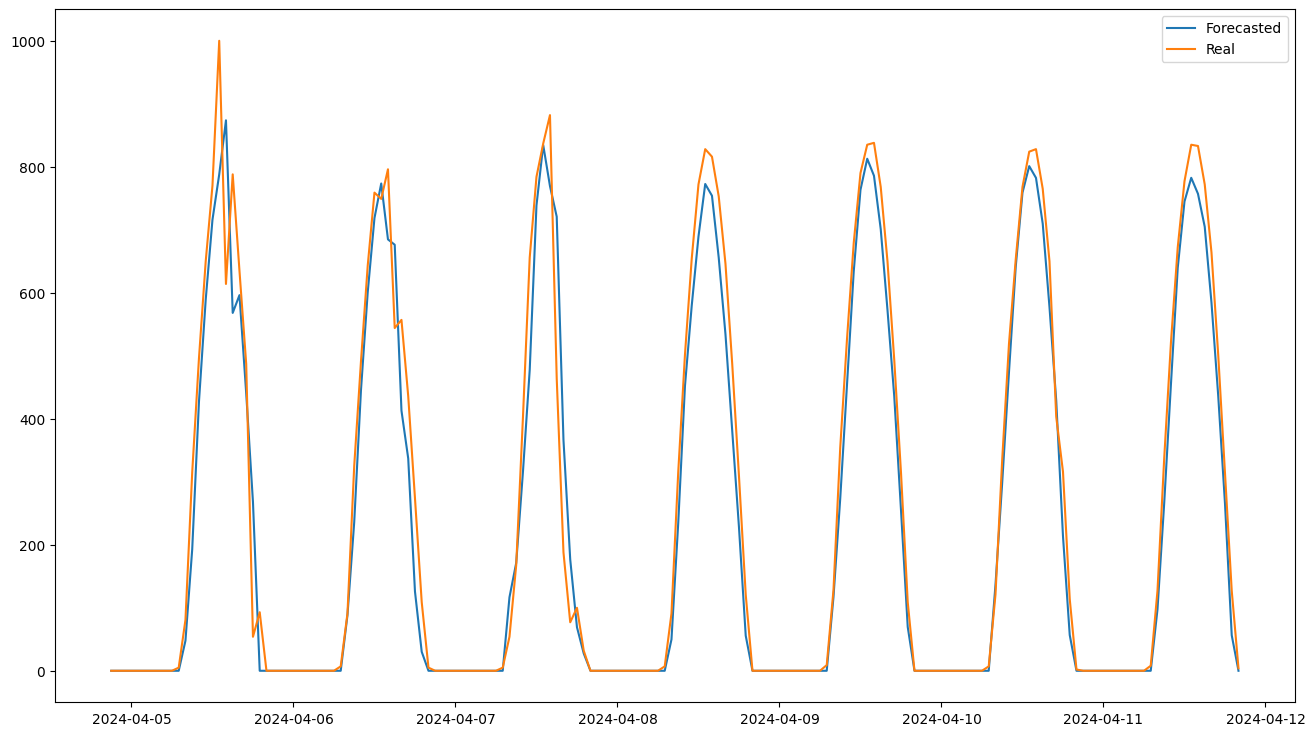

In [79]:
plt.figure(figsize=(16, 9))
plt.plot(test_results_solarrad["Val Predictions"][9:177], label="Forecasted")
plt.plot(test_results_solarrad["Real Data"][9:177], label="Real")
plt.legend()
plt.show()


In [80]:
mse_solarrad = mean_squared_error(test_results_solarrad["Real Data"], test_results_solarrad["Val Predictions"])
print(f"Mean Squared Error = {round(mse_solarrad, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_solarrad), 5)}")

ss_total = np.sum((test_results_solarrad["Real Data"] - test_results_solarrad["Real Data"].mean()) ** 2)
residual = np.sum((test_results_solarrad["Real Data"] - test_results_solarrad["Val Predictions"]) ** 2)
r_squared_solarrad = 1 - (residual / ss_total)

r_squared_solarrad, mse_solarrad   #0.8838


Mean Squared Error = 12060.42565 
Root Mean Squared Error = 109.81997


(0.8795562369451074, 12060.425647514161)

# Solar Pane Power Forecast

In [81]:
kwh_data = data[['temp', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation', 'Kwh']]
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,Kwh
datetime,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,0.0000
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,0.0000
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,0.0000
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,0.0000
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,0.0000
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,0.0592
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,0.0085
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,0.0000


In [82]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :6]]
        x.append(row)
        real_val = df_as_np[i + size][6]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [83]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :6])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)


,0,1,2,3,4,5
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640
1,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640
2,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640
3,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640
4,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640
5,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640
6,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640
7,-0.844550,0.677822,0.670561,0.898152,0.416156,-0.667640
8,-0.958452,0.918760,0.670561,0.898152,0.055669,-0.644949
9,-0.844550,0.924518,0.745665,0.530576,0.058244,-0.580657


In [84]:
df_scaled_kwh.index = data.index
df_scaled_kwh

,0,1,2,3,4,5
datetime,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640
...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206
2024-07-04 20:00:00,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108
2024-07-04 21:00:00,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603


In [85]:
df_scaled_kwh = df_scaled_kwh.reset_index(drop=True)
df_picked_kwh = kwh_data.reset_index(drop=True)

df_scaled_kwh = pd.concat([df_scaled_kwh, df_picked_kwh["Kwh"]], axis=1)
df_scaled_kwh


,0,1,2,3,4,5,Kwh
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,0.0000
1,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,0.0000
2,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,0.0000
3,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,0.0000
4,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,0.0000
...,...,...,...,...,...,...,...
21978,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206,0.0592
21979,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108,0.0085
21980,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603,0.0000
21981,0.750070,-0.179635,-0.219964,-1.601364,0.457355,-0.667640,0.0000


In [86]:
x_kwh, y_kwh = df_to_x_y(df_scaled_kwh, size=24)
x_kwh.shape, y_kwh.shape

x_train_kwh, y_train_kwh = x_kwh[:int(0.8*len(x_kwh))], y_kwh[:int(0.8*len(y_kwh))]
x_val_kwh, y_val_kwh = x_kwh[int(0.8*len(x_kwh)):int(0.9*len(x_kwh))], y_kwh[int(0.8*len(y_kwh)):int(0.9*len(y_kwh))]
x_test_kwh, y_test_kwh = x_kwh[int(0.9*len(x_kwh)):], y_kwh[int(0.9*len(y_kwh)):]

x_train_kwh.shape, y_train_kwh.shape, x_val_kwh.shape, y_val_kwh.shape, x_test_kwh.shape, y_test_kwh.shape

((17567, 24, 6), (17567,), (2196, 24, 6), (2196,), (2196, 24, 6), (2196,))

In [87]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

In [88]:
input_shape = (24, 6)

inputs = Input(shape=input_shape)

lstm_out = LSTM(128, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(128, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 24, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 24, 128)   │     69,120 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 128)   │        512 │ lstm_6[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_6         │ (None, 24, 128)   │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 24, 128)   │          0 │ attention_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 24, 128)   │     16,512 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 128)   │        512 │ dense_12[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 86,785 (339.00 KB)

 Trainable params: 86,273 (337.00 KB)

 Non-trainable params: 512 (2.00 KB)

In [89]:
model_1.fit(x_train_kwh, y_train_kwh, 
            validation_data=(x_val_kwh, y_val_kwh), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )


Epoch 1/40
546/549 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0501 - root_mean_squared_error: 0.2174
Epoch 1: val_loss improved from 2.05062 to 0.01431, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0499 - root_mean_squared_error: 0.2171 - val_loss: 0.0143 - val_root_mean_squared_error: 0.1198 - learning_rate: 0.0010
Epoch 2/40
546/549 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0115 - root_mean_squared_error: 0.1071
Epoch 2: val_loss improved from 0.01431 to 0.00803, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0115 - root_mean_squared_error: 0.1071 - val_loss: 0.0080 - val_root_mean_squared_error: 0.0898 - learning_rate: 0.0010
Epoch 3/40
545/549 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0085 - root_mean_squared_error: 0.0923
Epoch 3: val_loss did not improve from 0.00803
549/549 ━━━━━━━━━━━━━━━━━━━

In [90]:
test_predictions_kwh = model_1.predict(x_test_kwh).flatten()
test_results_kwh = pd.DataFrame({"Val Predictions": test_predictions_kwh, "Real Data": y_test_kwh})
test_results_kwh
test_results_kwh.index = kwh_data.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


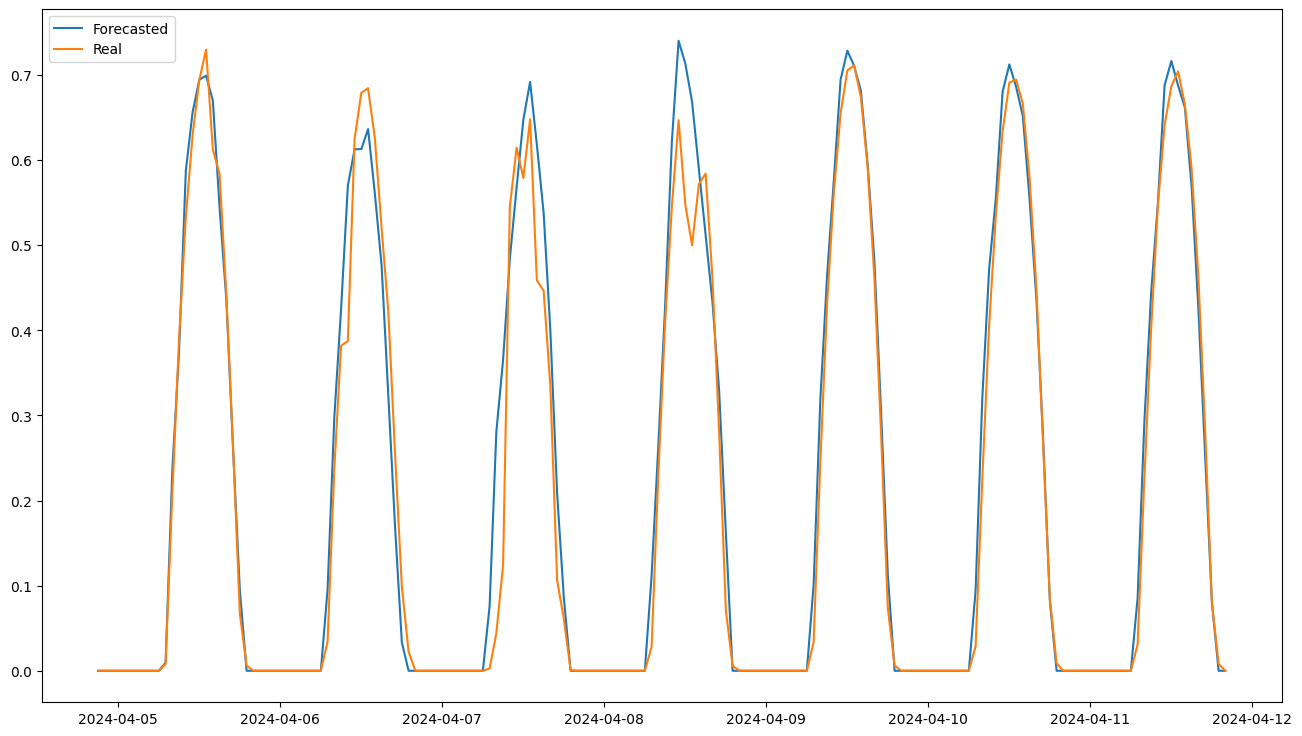

In [91]:
plt.figure(figsize=(16, 9))
plt.plot(test_results_kwh["Val Predictions"][9:177], label="Forecasted")
plt.plot(test_results_kwh["Real Data"][9:177], label="Real")
plt.legend()
plt.show()


In [92]:
mse_kwh = mean_squared_error(test_results_kwh["Real Data"], test_results_kwh["Val Predictions"])
print(f"Mean Squared Error = {round(mse_kwh, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_kwh), 5)}")

ss_total = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Real Data"].mean()) ** 2)
residual = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Val Predictions"]) ** 2)
r_squared_kwh = 1 - (residual / ss_total)

r_squared_kwh, mse_kwh 

Mean Squared Error = 0.00678 
Root Mean Squared Error = 0.08234


(0.8907532737710665, 0.006779737086034352)

# Predictions from Forecasted Values

In [93]:
weather_power_data = pd.DataFrame({'temp': test_predictions_temp, 
                                   'humidity' : test_predictions_humidity, 
                                   'cloudcover' : test_predictions_cloudcov,
                                   'solarradiation' : test_predictions_solarrad, 
                                   'Kwh' : test_predictions_kwh})

In [94]:
weather_power_data.head(), weather_power_data.shape

(        temp   humidity  cloudcover  solarradiation       Kwh
 0  17.955080  23.319565   12.181175      767.088989  0.758188
 1  19.573496  19.025589   11.760686      797.435547  0.726950
 2  20.978054  17.211210   10.251404      768.517212  0.655401
 3  21.787832  16.136129    9.257624      692.599976  0.552846
 4  22.832315  16.551971    8.267135      567.016663  0.416188,
 (2196, 5))

In [95]:
date_range = pd.date_range(start='2024/4/4 12:00:00', end='2024/7/4 23:00:00', freq='H')

weather_power_data.index = date_range

In [96]:
df_scaled_forecasted = scaler.transform(weather_power_data.iloc[:, :4])
df_scaled_forecasted = pd.DataFrame(df_scaled_forecasted)
df_scaled_forecasted.head(20)


ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- winddir
- windgust


In [220]:
df_scaled_forecasted.index = date_range

df_scaled_forecasted = pd.concat([df_scaled_forecasted, weather_power_data["Kwh"]], axis=1)
df_scaled_forecasted


,0,1,2,3,Kwh
2024-04-04 12:00:00,0.469518,-1.592436,-1.229211,2.045210,0.708725
2024-04-04 13:00:00,0.651123,-1.774876,-1.229211,2.135127,0.700305
2024-04-04 14:00:00,0.773240,-1.832970,-1.229211,2.040458,0.654785
2024-04-04 15:00:00,0.892574,-1.893860,-1.229211,1.760027,0.543584
2024-04-04 16:00:00,0.990967,-1.863594,-1.229211,1.315109,0.395813
...,...,...,...,...,...
2024-07-04 19:00:00,1.001293,-0.918057,0.733595,0.367389,0.144655
2024-07-04 20:00:00,0.961489,-0.801465,0.679233,-0.440382,0.040873
2024-07-04 21:00:00,0.815761,-0.638510,0.710260,-0.667640,0.000000
2024-07-04 22:00:00,0.623326,-0.182955,0.256216,-0.667640,0.000000


In [223]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :4]]
        x.append(row)
        real_val = df_as_np[i + size][4]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [224]:
x_forecast, y_forecast = df_to_x_y(df_scaled_forecasted, size=24)
x_forecast.shape, y_forecast.shape

((2172, 24, 4), (2172,))

In [225]:
forecasted_predictions = model_1.predict(x_forecast).flatten()


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [226]:
forecasted_predictions

array([0.6405505, 0.6456084, 0.594861 , ..., 0.       , 0.       ,
       0.       ], dtype=float32)

In [227]:
forecasted_predictions = pd.DataFrame(forecasted_predictions, columns= ["Forecasted"])

In [228]:
date_range_forecasted = pd.date_range(start='2024/4/5 12:00:00', end='2024/7/4 23:00:00', freq='H')

forecasted_predictions.index = date_range_forecasted

C:\Users\hercd\AppData\Local\Temp\ipykernel_2408\2249362329.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range_forecasted = pd.date_range(start='2024/4/5 12:00:00', end='2024/7/4 23:00:00', freq='H')


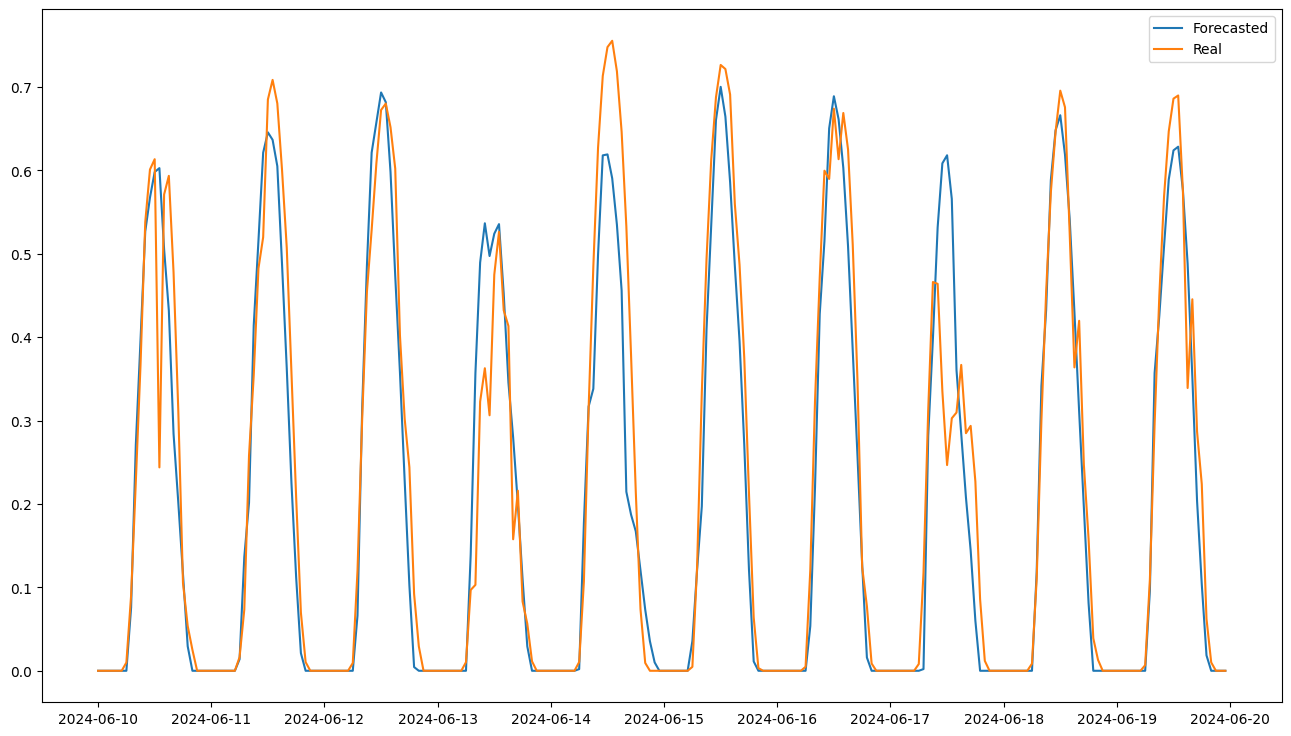

In [234]:
plt.figure(figsize=(16, 9))
plt.plot(forecasted_predictions[-600: -360: ], label="Forecasted")
plt.plot(test_results_kwh["Real Data"][-600: -360: ], label="Real")
plt.legend()
plt.show()


In [230]:
new_forecasted_df = pd.DataFrame({"Real Data": test_results_kwh["Real Data"][-2172: ], "forecasted_predictions" : forecasted_predictions['Forecasted']})

In [231]:
new_forecasted_df

,Real Data,forecasted_predictions
2024-04-05 12:00:00,0.6943,0.640550
2024-04-05 13:00:00,0.7297,0.645608
2024-04-05 14:00:00,0.6125,0.594861
2024-04-05 15:00:00,0.5837,0.508265
2024-04-05 16:00:00,0.4414,0.301022
...,...,...
2024-07-04 19:00:00,0.0592,0.109790
2024-07-04 20:00:00,0.0085,0.008636
2024-07-04 21:00:00,0.0000,0.000000
2024-07-04 22:00:00,0.0000,0.000000


In [232]:
mse_kwh_forecasted = mean_squared_error(new_forecasted_df["Real Data"], new_forecasted_df['forecasted_predictions'])
print(f"Mean Squared Error = {round(mse_kwh_forecasted, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_kwh_forecasted), 5)}")

ss_total = np.sum((new_forecasted_df["Real Data"] - new_forecasted_df["Real Data"].mean()) ** 2)
residual = np.sum((new_forecasted_df["Real Data"][-2172: ] - new_forecasted_df['forecasted_predictions']) ** 2)

r_squared_kwh_forecasted = 1 - (residual / ss_total)

r_squared_kwh_forecasted, mse_kwh_forecasted 

Mean Squared Error = 0.00799 
Root Mean Squared Error = 0.08939


(0.8709057741462973, 0.00799035484984431)

# For One Day Test!!

In [193]:
weather_power_data = pd.DataFrame({'Temperature': test_predictions_temp[-24:], 
                                   'Humidity' : test_predictions_humidity[-24:], 
                                   'CloudCover' : test_predictions_cloudcov[-24:],
                                   'SolarRad' : test_predictions_solarrad[-24:], 
                                   'Kwh' : test_predictions_kwh[-24:]})

In [ ]:
df_scaled_forecasted = scaler.transform(weather_power_data.iloc[:, :4])
df_scaled_forecasted = pd.DataFrame(df_scaled_forecasted)
df_scaled_forecasted.head(20)


In [108]:
date_range = pd.date_range(start='2024/7/4 00:00:00', end='2024/7/4 23:00:00', freq='H')


weather_power_data.index = date_range
weather_power_data

C:\Users\hercd\AppData\Local\Temp\ipykernel_2408\1421928105.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start='2024/7/4 00:00:00', end='2024/7/4 23:00:00', freq='H')


,Temperature,Humidity,Windgust,Winddir,CloudCover,SolarRad,Kwh
2024-07-04 00:00:00,18.649151,55.193768,20.957088,302.449127,86.073341,0.000000,0.000000
2024-07-04 01:00:00,19.232803,50.008091,20.972519,310.421570,85.808464,0.000000,0.000000
2024-07-04 02:00:00,18.867630,51.606022,17.571337,314.338165,87.321449,0.000000,0.000000
2024-07-04 03:00:00,18.989283,48.443401,14.270905,315.555023,85.692711,0.000000,0.000000
2024-07-04 04:00:00,17.104744,64.205063,15.794775,309.391754,91.756851,0.000000,0.000000
2024-07-04 05:00:00,15.975530,74.473488,12.422070,307.753937,91.245308,0.000000,0.000000
2024-07-04 06:00:00,15.771129,73.103951,12.143236,302.806366,89.895493,0.000000,0.000000
2024-07-04 07:00:00,17.428690,67.970329,14.260415,320.384064,77.796310,0.000000,0.134754
2024-07-04 08:00:00,18.130426,57.867649,15.527472,322.278839,78.388374,142.888809,0.326282
2024-07-04 09:00:00,17.542244,55.021931,20.983576,306.484436,78.643082,248.700928,0.478950


In [109]:
scaler = StandardScaler()
df_scaled_forecasted = scaler.fit_transform(weather_power_data.iloc[:, :6])
df_scaled_forecasted = pd.DataFrame(df_scaled_forecasted)
df_scaled_forecasted.index = date_range
df_scaled_forecasted.head(20)

,0,1,2,3,4,5
2024-07-04 00:00:00,-0.551866,0.512585,0.438203,0.694389,0.654742,-0.878628
2024-07-04 01:00:00,-0.352287,0.144242,0.441593,0.840777,0.640603,-0.878628
2024-07-04 02:00:00,-0.477157,0.257745,-0.305670,0.912692,0.721364,-0.878628
2024-07-04 03:00:00,-0.435558,0.033101,-1.030797,0.935036,0.634425,-0.878628
2024-07-04 04:00:00,-1.079973,1.152664,-0.695993,0.821868,0.958117,-0.878628
2024-07-04 05:00:00,-1.466105,1.882038,-1.436999,0.791794,0.930812,-0.878628
2024-07-04 06:00:00,-1.535999,1.784759,-1.498261,0.700948,0.858761,-0.878628
2024-07-04 07:00:00,-0.969200,1.420114,-1.033102,1.023706,0.212929,-0.878628
2024-07-04 08:00:00,-0.729242,0.702513,-0.754721,1.058497,0.244533,-0.303813
2024-07-04 09:00:00,-0.930370,0.500379,0.444023,0.768484,0.258129,0.121849


In [110]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size + 1):
        row = [a for a in df_as_np[i: i+size, :7]]
        x.append(row)
       
    
    return np.array(x)


In [111]:
df_scaled_forecasted = pd.concat([df_scaled_forecasted, weather_power_data["Kwh"]], axis=1)
df_scaled_forecasted


,0,1,2,3,4,5,Kwh
2024-07-04 00:00:00,-0.551866,0.512585,0.438203,0.694389,0.654742,-0.878628,0.000000
2024-07-04 01:00:00,-0.352287,0.144242,0.441593,0.840777,0.640603,-0.878628,0.000000
2024-07-04 02:00:00,-0.477157,0.257745,-0.305670,0.912692,0.721364,-0.878628,0.000000
2024-07-04 03:00:00,-0.435558,0.033101,-1.030797,0.935036,0.634425,-0.878628,0.000000
2024-07-04 04:00:00,-1.079973,1.152664,-0.695993,0.821868,0.958117,-0.878628,0.000000
2024-07-04 05:00:00,-1.466105,1.882038,-1.436999,0.791794,0.930812,-0.878628,0.000000
2024-07-04 06:00:00,-1.535999,1.784759,-1.498261,0.700948,0.858761,-0.878628,0.000000
2024-07-04 07:00:00,-0.969200,1.420114,-1.033102,1.023706,0.212929,-0.878628,0.134754
2024-07-04 08:00:00,-0.729242,0.702513,-0.754721,1.058497,0.244533,-0.303813,0.326282
2024-07-04 09:00:00,-0.930370,0.500379,0.444023,0.768484,0.258129,0.121849,0.478950


In [112]:
x_forecast= df_to_x_y(df_scaled_forecasted, size=24)
x_forecast.shape

(1, 24, 7)

In [113]:
x_forecast

array([[[-0.5518656 ,  0.512585  ,  0.43820313,  0.6943888 ,
          0.654742  , -0.8786277 ,  0.        ],
        [-0.35228676,  0.14424245,  0.44159335,  0.8407768 ,
          0.64060336, -0.8786277 ,  0.        ],
        [-0.47715706,  0.2577447 , -0.3056698 ,  0.91269237,
          0.7213637 , -0.8786277 ,  0.        ],
        [-0.4355582 ,  0.03310136, -1.0307975 ,  0.935036  ,
          0.6344247 , -0.8786277 ,  0.        ],
        [-1.0799725 ,  1.1526642 , -0.69599265,  0.8218676 ,
          0.95811725, -0.8786277 ,  0.        ],
        [-1.466105  ,  1.8820382 , -1.4369993 ,  0.79179436,
          0.93081206, -0.8786277 ,  0.        ],
        [-1.5359994 ,  1.7847589 , -1.4982609 ,  0.7009483 ,
          0.85876137, -0.8786277 ,  0.        ],
        [-0.9691998 ,  1.4201139 , -1.0331022 ,  1.0237057 ,
          0.21292944, -0.8786277 ,  0.13475358],
        [-0.7292424 ,  0.70251286, -0.75472087,  1.0584971 ,
          0.2445327 , -0.30381304,  0.32628193],
        [-

In [ ]:
forecasted_predictions = model_1.predict(x_forecast).flatten()
forecasted_predictions_df = pd.DataFrame(forecasted_predictions, index= date_range)

In [254]:
data['Kwh'][-24:]

datetime
2024-07-04 00:00:00    0.0000
2024-07-04 01:00:00    0.0000
2024-07-04 02:00:00    0.0000
2024-07-04 03:00:00    0.0000
2024-07-04 04:00:00    0.0000
2024-07-04 05:00:00    0.0000
2024-07-04 06:00:00    0.0053
2024-07-04 07:00:00    0.0739
2024-07-04 08:00:00    0.1635
2024-07-04 09:00:00    0.3776
2024-07-04 10:00:00    0.4861
2024-07-04 11:00:00    0.6202
2024-07-04 12:00:00    0.6260
2024-07-04 13:00:00    0.6692
2024-07-04 14:00:00    0.5754
2024-07-04 15:00:00    0.2240
2024-07-04 16:00:00    0.1976
2024-07-04 17:00:00    0.1672
2024-07-04 18:00:00    0.2298
2024-07-04 19:00:00    0.0592
2024-07-04 20:00:00    0.0085
2024-07-04 21:00:00    0.0000
2024-07-04 22:00:00    0.0000
2024-07-04 23:00:00    0.0000
Name: Kwh, dtype: float64

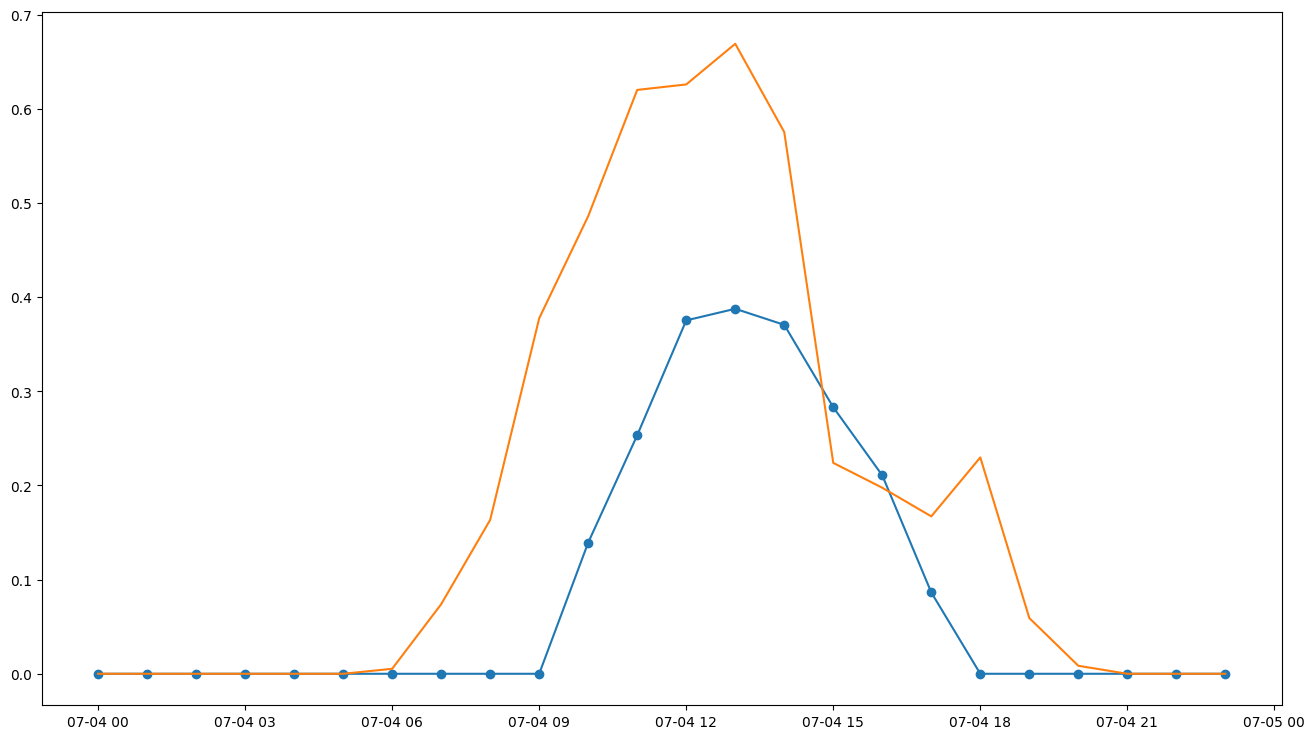

In [253]:
plt.figure(figsize= (16, 9))
plt.plot(forecasted_predictions_df, marker = 'o')
plt.plot(data['Kwh'][-24:])
plt.show()

# Multi output Test

In [196]:
kwh_data = data[['temp', 'humidity', 'cloudcover', 'solarradiation', 'Kwh']]
kwh_data

,temp,humidity,cloudcover,solarradiation,Kwh
datetime,,,,,
2022-01-01 00:00:00,6.0,75.51,0.0,0.0,0.0000
2022-01-01 01:00:00,6.0,75.51,0.0,0.0,0.0000
2022-01-01 02:00:00,4.9,81.61,40.9,0.0,0.0000
2022-01-01 03:00:00,4.0,80.80,38.0,0.0,0.0000
2022-01-01 04:00:00,3.0,93.14,41.7,0.0,0.0000
...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,79.3,207.0,0.0592
2024-07-04 20:00:00,23.0,40.87,81.7,103.0,0.0085
2024-07-04 21:00:00,21.0,49.39,63.7,9.0,0.0000


In [197]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :4]]
        x.append(row)
        real_val = df_as_np[i + size][4]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [198]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :4])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)


,0,1,2,3
0,-0.844550,0.677822,-1.229211,-0.667640
1,-0.844550,0.677822,-1.229211,-0.667640
2,-0.969842,0.947992,-0.176073,-0.667640
3,-1.072353,0.912117,-0.250745,-0.667640
4,-1.186254,1.458657,-0.155474,-0.667640
5,-1.186254,1.457328,-0.209547,-0.667640
6,-1.072353,1.177858,-0.078226,-0.667640
7,-0.844550,0.677822,0.416156,-0.667640
8,-0.958452,0.918760,0.055669,-0.644949
9,-0.844550,0.924518,0.058244,-0.580657


In [199]:
df_scaled_kwh.index = data.index

df_scaled_kwh = df_scaled_kwh.reset_index(drop=True)
df_picked_kwh = kwh_data.reset_index(drop=True)

df_scaled_kwh = pd.concat([df_scaled_kwh, df_picked_kwh["Kwh"]], axis=1)
df_scaled_kwh


,0,1,2,3,Kwh
0,-0.844550,0.677822,-1.229211,-0.667640,0.0000
1,-0.844550,0.677822,-1.229211,-0.667640,0.0000
2,-0.969842,0.947992,-0.176073,-0.667640,0.0000
3,-1.072353,0.912117,-0.250745,-0.667640,0.0000
4,-1.186254,1.458657,-0.155474,-0.667640,0.0000
...,...,...,...,...,...
21978,1.205675,-0.843987,0.812692,0.115206,0.0592
21979,1.091774,-0.856388,0.874490,-0.278108,0.0085
21980,0.863971,-0.479036,0.411006,-0.633603,0.0000
21981,0.750070,-0.179635,0.457355,-0.667640,0.0000


In [200]:
x_kwh, y_kwh = df_to_x_y(df_scaled_kwh, size=24)
x_kwh.shape, y_kwh.shape

x_train_kwh, y_train_kwh = x_kwh[:int(0.8*len(x_kwh))], y_kwh[:int(0.8*len(y_kwh))]
x_val_kwh, y_val_kwh = x_kwh[int(0.8*len(x_kwh)):int(0.9*len(x_kwh))], y_kwh[int(0.8*len(y_kwh)):int(0.9*len(y_kwh))]
x_test_kwh, y_test_kwh = x_kwh[int(0.9*len(x_kwh)):], y_kwh[int(0.9*len(y_kwh)):]

x_train_kwh.shape, y_train_kwh.shape, x_val_kwh.shape, y_val_kwh.shape, x_test_kwh.shape, y_test_kwh.shape

((17567, 24, 4), (17567,), (2196, 24, 4), (2196,), (2196, 24, 4), (2196,))

In [203]:
input_shape = (24, 4)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 24, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_13 (LSTM)      │ (None, 24, 64)    │     17,664 │ input_layer_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_13[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_16        │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 24, 64)    │          0 │ attention_16[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 24, 64)    │      4,160 │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense_31[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,401 (87.50 KB)

 Trainable params: 22,145 (86.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [204]:
model_1.fit(x_train_kwh, y_train_kwh, 
            validation_data=(x_val_kwh, y_val_kwh), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback]
            )


Epoch 1/40
548/549 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0662 - root_mean_squared_error: 0.2438
Epoch 1: val_loss did not improve from 0.00437
549/549 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0661 - root_mean_squared_error: 0.2436 - val_loss: 0.0234 - val_root_mean_squared_error: 0.1530
Epoch 2/40
545/549 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0144 - root_mean_squared_error: 0.1200
Epoch 2: val_loss did not improve from 0.00437
549/549 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0144 - root_mean_squared_error: 0.1200 - val_loss: 0.0089 - val_root_mean_squared_error: 0.0943
Epoch 3/40
548/549 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0104 - root_mean_squared_error: 0.1020
Epoch 3: val_loss did not improve from 0.00437
549/549 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0104 - root_mean_squared_error: 0.1020 - val_loss: 0.0090 - val_root_mean_squared_error: 0.0948
Epoch 4/40
545/549 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0084 - root_mean_squared_error: 0.0917
Epoch 4: va

In [205]:
test_predictions_kwh = model_1.predict(x_test_kwh).flatten()
test_results_kwh = pd.DataFrame({"Val Predictions": test_predictions_kwh, "Real Data": y_test_kwh})
test_results_kwh
test_results_kwh.index = kwh_data.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


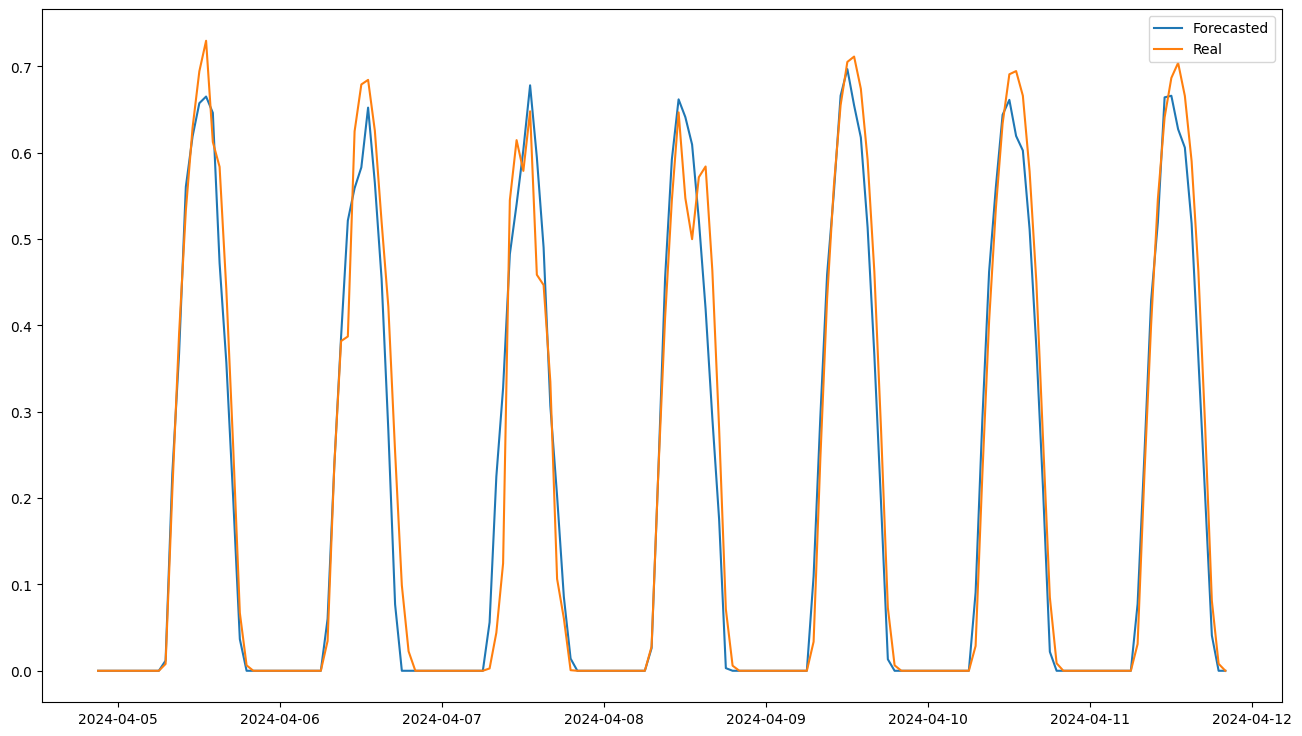

In [206]:
plt.figure(figsize=(16, 9))
plt.plot(test_results_kwh["Val Predictions"][9:177], label="Forecasted")
plt.plot(test_results_kwh["Real Data"][9:177], label="Real")
plt.legend()
plt.show()


In [207]:
mse_kwh = mean_squared_error(test_results_kwh["Real Data"], test_results_kwh["Val Predictions"])
print(f"Mean Squared Error = {round(mse_kwh, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_kwh), 5)}")

ss_total = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Real Data"].mean()) ** 2)
residual = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Val Predictions"]) ** 2)
r_squared_kwh = 1 - (residual / ss_total)

r_squared_kwh, mse_kwh 

Mean Squared Error = 0.00678 
Root Mean Squared Error = 0.08235


(0.8907258225224353, 0.00678144068169188)